## Loan Approval Prediction Using Logistic Regression

This project builds a logistic regression model to predict loan approval outcomes using structured applicant data prepared in MySQL and analyzed in Tableau. The objective is to assess predictive performance and validate whether credit score, income, and employment stability emerge as statistically significant approval drivers.

### Objective

Develop an interpretable predictive model to estimate loan approval outcomes based on applicant financial and demographic attributes.

The goal is to:
- Evaluate whether applicant characteristics can reliably predict approval decisions
- Identify the most influential approval drivers
- Compare model findings with previously developed dashboard insights
- Demonstrate end-to-end analytics capability (SQL → BI → ML)

### Dataset

- **Source:** Kaggle
- **Size:** 1,000 records
- **Features:** Demographics, financial attributes, employment status, and loan approval outcome.
- **Dataset link:** [Loan Approval Dataset](https://www.kaggle.com/datasets/amineipad/loan-approval-dataset)

### Import required libraries

Import core Python libraries for data manipulation, visualization, model training, and evaluation.

In [135]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Visualization
import matplotlib.pyplot as plt

# Model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# For encoding categorical variables
from sklearn.preprocessing import OneHotEncoder

### Load the dataset
Load the cleaned dataset exported from MySQL and preview the structure.

In [136]:
# Load dataset
df = pd.read_csv("data/loan_applications_clean.csv")

# Display first few rows
df.head()

,applicant_id,age,gender,marital_status,employment_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
0,1,59,Male,Divorced,Unemployed,100073.0,7169.0,793,1,1,1
1,2,49,Male,Married,Employed,112197.0,23556.0,789,0,2,1
2,3,35,Male,Divorced,Unemployed,84429.0,27052.0,372,1,4,0
3,4,63,Female,Single,Self-employed,124195.0,11313.0,808,3,4,1
4,5,28,Female,Married,Unemployed,81627.0,13315.0,689,0,1,1


### Basic inspection
Examine dataset dimensions, data types, and missing values to validate data integrity before modeling.

In [137]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   applicant_id          1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   marital_status        1000 non-null   object 
 4   employment_status     1000 non-null   object 
 5   annual_income         1000 non-null   float64
 6   loan_amount           1000 non-null   float64
 7   credit_score          1000 non-null   int64  
 8   num_dependents        1000 non-null   int64  
 9   existing_loans_count  1000 non-null   int64  
 10  loan_approved         1000 non-null   int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 86.1+ KB


In [138]:
# Check shape
df.shape

(1000, 11)

In [139]:
# Check for missing values
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
employment_status       0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
loan_approved           0
dtype: int64

### Define target features 
Separate the predictor variables (features) from the target variable (`loan_approved`). This defines what the model will learn from and what it will predict.


In [140]:
# Drop identifier column
df_model = df.drop(columns=["applicant_id"])

# Define target variable
y = df_model["loan_approved"]

# Define feature matrix
X = df_model.drop(columns=["loan_approved"])

X.head()

,age,gender,marital_status,employment_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count
0,59,Male,Divorced,Unemployed,100073.0,7169.0,793,1,1
1,49,Male,Married,Employed,112197.0,23556.0,789,0,2
2,35,Male,Divorced,Unemployed,84429.0,27052.0,372,1,4
3,63,Female,Single,Self-employed,124195.0,11313.0,808,3,4
4,28,Female,Married,Unemployed,81627.0,13315.0,689,0,1


### Identify Categorical and Numerical Features

Separate categorical and numerical variables to prepare for encoding. Logistic regression requires numeric inputs.

In [141]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Identify numerical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:")
for col in categorical_cols:
    print(f" - {col}")

print("\nNumerical Features:")
for col in numerical_cols:
    print(f" - {col}")

Categorical Features:
 - gender
 - marital_status
 - employment_status

Numerical Features:
 - age
 - annual_income
 - loan_amount
 - credit_score
 - num_dependents
 - existing_loans_count


### Exploratory Data Analysis

#### Target Distribution
Assess class balance to understand baseline classification difficulty.

In [142]:
df["loan_approved"].value_counts()

loan_approved
1    729
0    271
Name: count, dtype: int64

In [143]:
df["loan_approved"].value_counts(normalize=True)

loan_approved
1    0.729
0    0.271
Name: proportion, dtype: float64

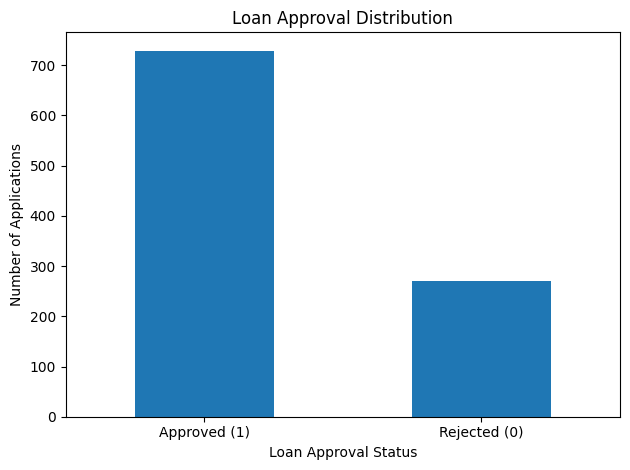

In [144]:
df["loan_approved"].value_counts().plot(kind="bar")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approval Status")
plt.ylabel("Number of Applications")

plt.xticks(ticks=[0, 1], labels=["Approved (1)", "Rejected (0)"], rotation=0)

plt.tight_layout()
plt.show()

### Approval Rate by Binned Numerical Variables
Instead of raw scatter, we aggregate properly.

#### Credit Score Trend

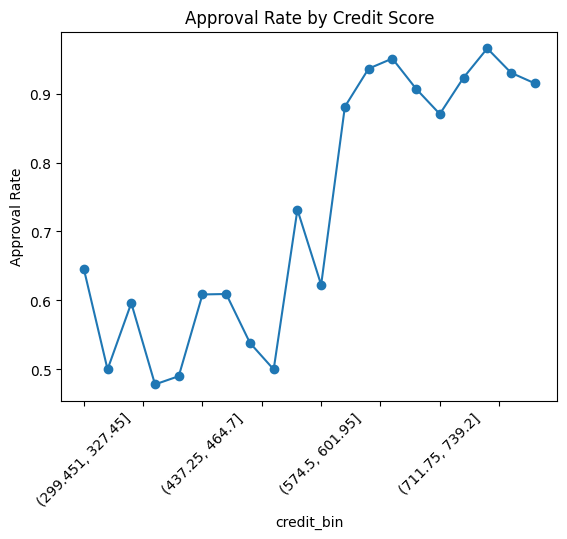

In [145]:
df["credit_bin"] = pd.cut(df["credit_score"], bins=20)

credit_trend = df.groupby("credit_bin", observed=True)["loan_approved"].mean()

credit_trend.plot(marker="o")
plt.title("Approval Rate by Credit Score")
plt.xticks(rotation=45)
plt.ylabel("Approval Rate")
plt.show()

Approval rates increase monotonically with credit score, with a sharp inflection around mid-range scores and a plateau at higher scores. This confirms credit score as a dominant approval driver and supports its strong positive coefficient in the logistic regression model.

#### Loan to Income Ratio Trend

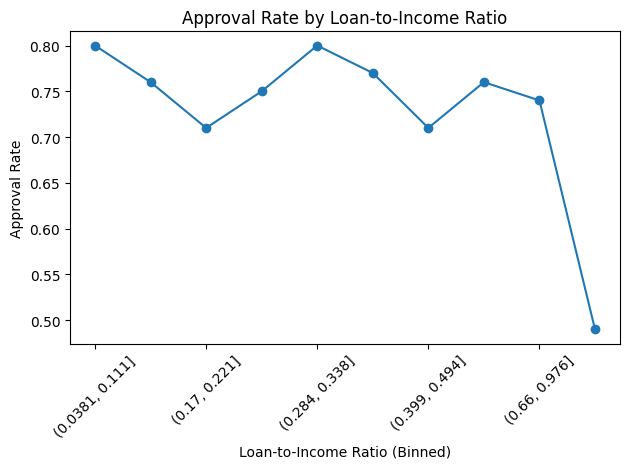

In [146]:
# Create LTI bins
df["lti_bin"] = pd.qcut(
    df["loan_amount"] / df["annual_income"],
    q=10,
    duplicates="drop"
)

# Explicitly set observed=True to silence FutureWarning
lti_trend = df.groupby("lti_bin", observed=True)["loan_approved"].mean()

# Plot
lti_trend.plot(marker="o")
plt.title("Approval Rate by Loan-to-Income Ratio")
plt.xlabel("Loan-to-Income Ratio (Binned)")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Approval probability declines as loan-to-income ratio increases, with the sharpest drop observed in the highest borrowing burden segment. This confirms financial leverage as a meaningful negative driver of loan approval.

### Correlation Matrix

Compute and visualize the correlation matrix of numerical features to assess linear relationships, identify potential multicollinearity, and evaluate associations with the target variable (loan_approved).

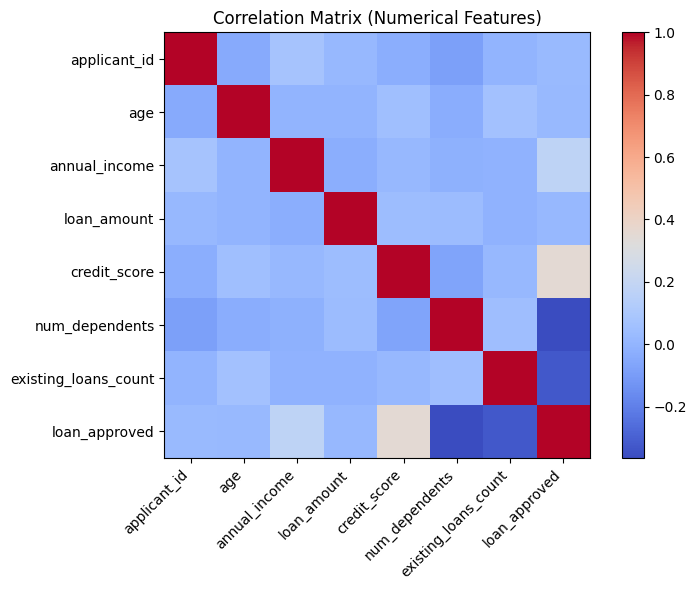

In [147]:
# Recalculate numerical columns from df
numerical_cols_df = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

corr = df[numerical_cols_df].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()

**Interpretation**

The correlation matrix indicates that credit score has the strongest positive linear relationship with loan approval, while number of dependents and existing loans show moderate negative relationships. Annual income exhibits a mild positive association with approval. No extreme correlations are observed among predictors, suggesting limited multicollinearity risk. Overall, the correlation patterns align with expected credit risk behavior and support subsequent model findings.

### Feature Engineering
Create financial ratio and log-transformed variables to improve linear separability and model stability.

#### Add Loan-to-Income Ratio

In [148]:
# Avoid division by zero (defensive programming)
X["loan_to_income_ratio"] = X["loan_amount"] / X["annual_income"]

#### Add Log Transformation

In [149]:
X["log_income"] = np.log1p(X["annual_income"])
X["log_loan_amount"] = np.log1p(X["loan_amount"])

#### Update Numerical Columns

In [150]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Updated Numerical Features:")
for col in numerical_cols:
    print(f" - {col}")

Updated Numerical Features:
 - age
 - annual_income
 - loan_amount
 - credit_score
 - num_dependents
 - existing_loans_count
 - loan_to_income_ratio
 - log_income
 - log_loan_amount


### Encode Categorical Variables
Convert categorical variables into numerical format using one-hot encoding. We drop the first category to prevent multicollinearity in logistic regression.

In [151]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_encoded.shape

(1000, 14)

In [152]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1000 non-null   int64  
 1   annual_income                    1000 non-null   float64
 2   loan_amount                      1000 non-null   float64
 3   credit_score                     1000 non-null   int64  
 4   num_dependents                   1000 non-null   int64  
 5   existing_loans_count             1000 non-null   int64  
 6   loan_to_income_ratio             1000 non-null   float64
 7   log_income                       1000 non-null   float64
 8   log_loan_amount                  1000 non-null   float64
 9   gender_Male                      1000 non-null   bool   
 10  marital_status_Married           1000 non-null   bool   
 11  marital_status_Single            1000 non-null   bool   
 12  employment_status_Sel

### Train-Test Split

Split the dataset into training and testing sets to evaluate model performance on unseen data. This prevents overly optimistic results caused by testing on training data.

We will use an 80/20 split and stratify on the target to preserve the approval/rejection ratio.

In [153]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((800, 14), (200, 14))

### Scale numerical features 
Standardize numerical features to improve logistic regression convergence and ensure stable, reliable coefficient estimation.

In [154]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

### Train Logistic Regression Model
Train a baseline logistic regression model to predict loan approvals. Logistic regression is widely used for binary classification and is interpretable for identifying key approval drivers.

In [155]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Evaluate model performance 

Evaluate model performance using multiple metrics to avoid relying only on accuracy. We will compute accuracy, precision, recall, F1-score, and ROC-AUC, plus a confusion matrix.

In [156]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

Accuracy:  0.895
Precision: 0.903
Recall:    0.959
F1 Score:  0.930
ROC-AUC:   0.962


**Interpretation:**

The model performs very well overall. It correctly classifies about 89.5% of loan applications, which means most predictions are accurate.

A precision of 0.903 shows that when the model predicts an approval, it is correct about 90% of the time. This suggests relatively few risky approvals.

A recall of 0.959 means the model successfully identifies almost all applicants who should be approved. It rarely misses qualified applicants.

The F1 score of 0.930 confirms a strong balance between precision and recall.

Most importantly, the ROC-AUC of 0.962 indicates excellent ability to distinguish between approved and rejected applicants. In simple terms, the model is very effective at ranking higher-risk and lower-risk applicants correctly.

### Interpret Logistic Regression Coefficients

Analyze logistic regression coefficients and corresponding odds ratios to determine the direction and magnitude of each feature’s impact on loan approval probability, translating statistical outputs into business-relevant insights.

#### Extract coefficients
Extract model coefficients from the trained logistic regression to quantify each feature’s influence on the prediction outcome and enable feature importance analysis.

In [157]:
# Extract coefficients
coefficients = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": log_reg.coef_[0]
})

# Sort by absolute importance
coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Abs_Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient,Abs_Coefficient
13,employment_status_Unemployed,-3.332092,3.332092
4,num_dependents,-1.993803,1.993803
5,existing_loans_count,-1.831891,1.831891
3,credit_score,1.572899,1.572899
7,log_income,1.551377,1.551377
1,annual_income,-0.899808,0.899808
12,employment_status_Self-employed,0.716169,0.716169
6,loan_to_income_ratio,-0.657063,0.657063
2,loan_amount,0.471492,0.471492
9,gender_Male,0.172060,0.172060


**Interpretation:** 

Model interpretation revealed employment status, credit score, and financial burden variables (dependents and existing loans) as the most influential approval drivers.

#### Convert Coefficients to Odd Ratios

- If Odds_Ratio > 1 → increases approval odds
- If Odds_Ratio < 1 → decreases approval odds

In [158]:
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])
coefficients.sort_values("Abs_Coefficient", ascending=False).head(10)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
13,employment_status_Unemployed,-3.332092,3.332092,0.035718
4,num_dependents,-1.993803,1.993803,0.136177
5,existing_loans_count,-1.831891,1.831891,0.160110
3,credit_score,1.572899,1.572899,4.820601
7,log_income,1.551377,1.551377,4.717961
1,annual_income,-0.899808,0.899808,0.406648
12,employment_status_Self-employed,0.716169,0.716169,2.046578
6,loan_to_income_ratio,-0.657063,0.657063,0.518371
2,loan_amount,0.471492,0.471492,1.602383
9,gender_Male,0.172060,0.172060,1.187749


**Interpretation:**

Employment stability and financial burden are the strongest drivers of approval. Unemployment sharply reduces approval odds, while higher dependents and existing loans decrease likelihood. Credit score and income significantly increase approval probability, and the engineered loan-to-income ratio confirms that higher borrowing burden lowers approval chances. Overall, results align with expected credit risk behavior.

### Confusion Matrix Analysis

Evaluate classification errors to understand trade-offs between false approvals and false rejections.<br>
Structure:
- Top-left → True Negatives (Rejected correctly)
- Top-right → False Positives (Incorrect approvals)
- Bottom-left → False Negatives (Missed approvals)
- Bottom-right → True Positives (Approved correctly)


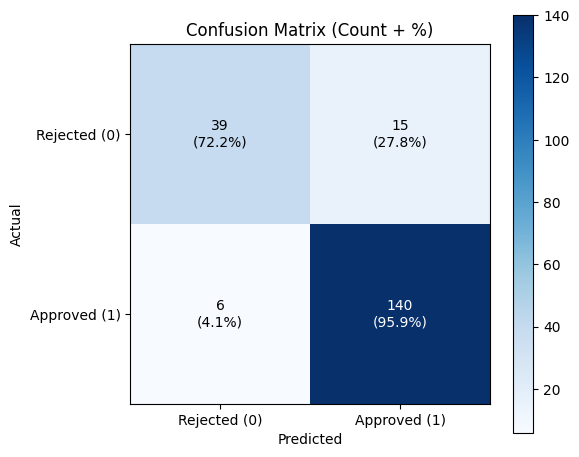

In [159]:
cm = confusion_matrix(y_test, y_pred)

# Calculate row-wise percentages
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Count + %)")

# Add count and percentage labels
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm_percent[i, j]
        plt.text(j, i, f"{count}\n({percent:.1f}%)",
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.xticks([0,1], ["Rejected (0)", "Approved (1)"])
plt.yticks([0,1], ["Rejected (0)", "Approved (1)"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()
plt.tight_layout()
plt.show()

**Interpretation:** 

The model correctly identifies 95.9% of approved applicants (140 out of 146), demonstrating very strong sensitivity and aligning with the high recall score. Only 4.1% of approved cases were incorrectly rejected, indicating minimal missed opportunities.

For rejected applications, the model correctly classifies 72.2% (39 out of 54), while 27.8% were incorrectly approved. This reflects a moderate false approval rate, which represents potential lending risk.

Overall, the model prioritizes capturing approved applicants while maintaining reasonable control over false approvals. This behavior is consistent with the high recall and strong overall performance observed in the evaluation metrics.

### ROC Curve Analysis 

Plot the Receiver Operating Characteristic (ROC) curve to evaluate the model’s ability to distinguish between approved and rejected applicants across all classification thresholds. The curve illustrates the trade-off between the true positive rate (sensitivity) and false positive rate, while the Area Under the Curve (AUC) summarizes overall discrimination performance.

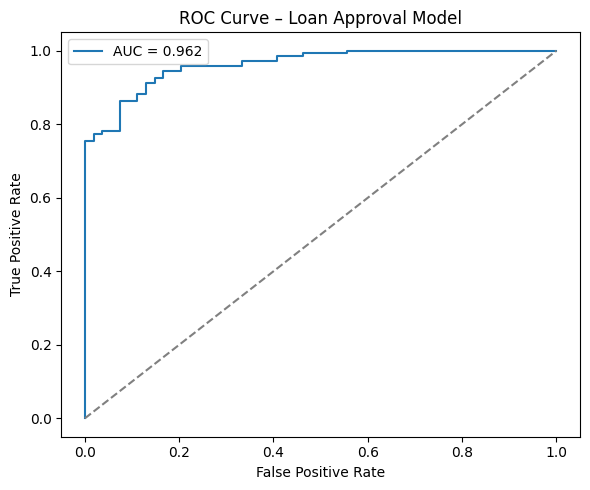

In [161]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.title("ROC Curve – Loan Approval Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation**

The ROC curve lies well above the diagonal reference line, indicating strong classification performance beyond random guessing. With an AUC of 0.962, the model demonstrates excellent discrimination ability, meaning it effectively ranks approved applicants higher than rejected applicants across threshold levels. This confirms that the model has strong predictive power and robust separation between low-risk and high-risk applicants.